In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import os

## Module for plotting "chromatograms" generated from the SEC_SAXS file

In [2]:
import os

# Create a pop-up window to select a file and default to ./output_chromatogram
root = tk.Tk()
root.withdraw()  # Hide the root window
# Bring the window to the front
root.lift()
root.attributes('-topmost', True)
root.after_idle(lambda: root.attributes('-topmost', False))

initial_dir = os.path.abspath(os.path.join(os.getcwd(), 'output_chromatogram'))
os.makedirs(initial_dir, exist_ok=True)  # ensure folder exists

file_paths = filedialog.askopenfilenames(title = "Select data file", initialdir=initial_dir, filetypes=[(".dat", "*.dat"), ("All files", "*.*")])

In [3]:
df_chr = {}
for file_path in file_paths:
    df_chr[file_path] = pd.read_csv(file_path, sep= r'\s+', header=None, skiprows=1, engine='python')

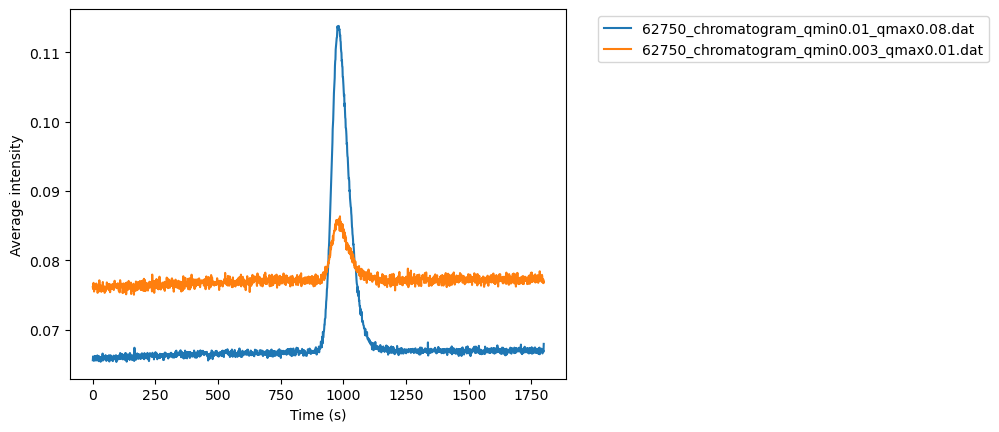

In [4]:
plt.close('all')
plt.figure()
scale = [6.5,0.9,110]
bkg = [0,0.05,0.05]
for idx, (file_path, data) in enumerate(df_chr.items()):
    time = data.iloc[:,0]
    intensity = data.iloc[:,1]
    plt.plot(time, intensity*scale[idx]-bkg[idx], label=file_path.split('/')[-1])  # Plot with filename as label

plt.xlabel('Time (s)')
plt.ylabel('Average intensity')
plt.yscale('linear')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

## Module for plotting I vs. q generated from the SEC_SAXS file

In [11]:

# Create a pop-up window to select a file
root = tk.Tk()
root.withdraw()  # Hide the root window
# Bring the window to the front
root.lift()
root.attributes('-topmost', True)
root.after_idle(lambda: root.attributes('-topmost', False))

file_paths = filedialog.askopenfilenames(title = "Select data file", filetypes=[(".dat", "*.dat"), ("All files", "*.*")])

In [12]:
df = {}
for file_path in file_paths:
    df[file_path] = pd.read_csv(file_path, sep= r'\s+', header=None, skiprows=1, engine='python')

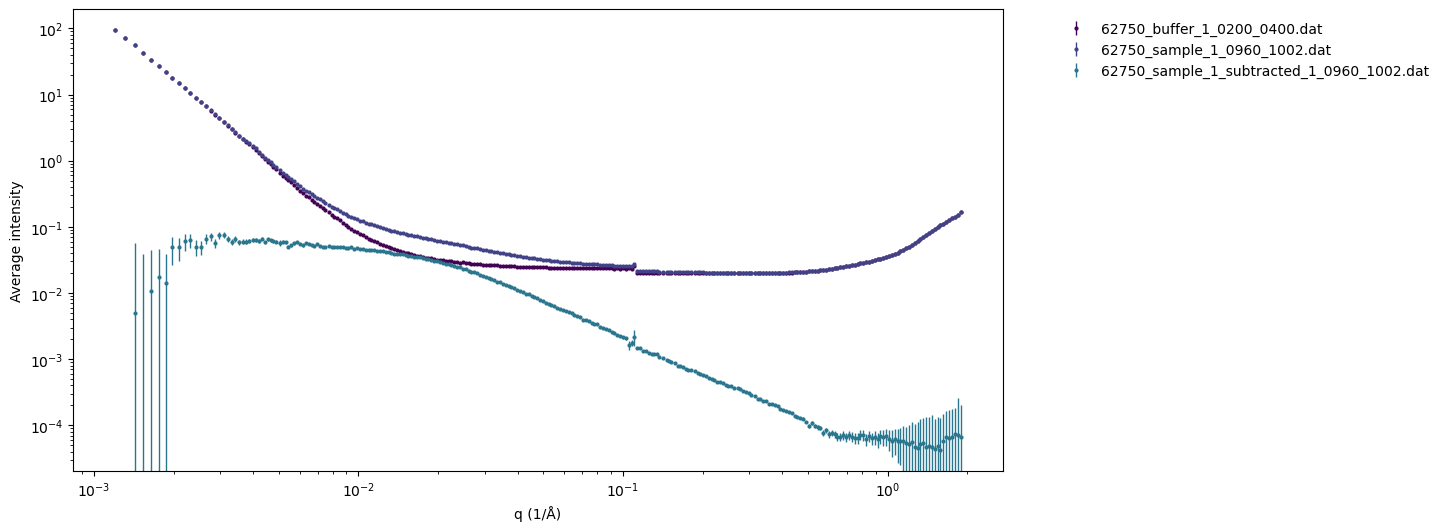

In [13]:
plt.figure(figsize=(12,6))
colormap = plt.get_cmap('viridis')
count = 0
for file_path, data in df.items():
    q = data.iloc[:,0]
    intensity = data.iloc[:,1]
    err = data.iloc[:,2] if data.shape[1] > 2 else None
    plt.errorbar(q, intensity, yerr=err, fmt='o', markersize = 2, elinewidth= 1,label=file_path.split('/')[-1], color = colormap((count) % colormap.N))  # Plot with filename as label
    count += 50

plt.xlabel('q (1/Å)')
plt.ylabel('Average intensity')
plt.yscale('log')
plt.xscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=False)
plt.show()